## Gelişmiş Davranışsal Kredi Risk Modeli (Behavioral Core)
Bu notebook, MVP aşamasında kurulan temel risk tahminleme mantığını, daha karmaşık özellikler ve hiper-parametre optimizasyonu ile ileri seviyeye taşımayı hedefler.

### Veri Hazırlama Stratejimiz
1. **Feature Engineering:** `fast_tx` (hızlı işlem) ve `is_night_transaction` (gece işlemi) gibi ham veride bulunmayan, ancak risk sinyali taşıyan davranışsal özellikler türetilmiştir.
2. **Sayısal Optimizasyon:** Arrow/Parquet formatından gelen metin tabanlı finansal veriler (Income/Debt), matematiksel işlemlere uygun hale getirilmek için temizlenmiştir.
3. **Dinamik Eşikleme (Quantile Method):** Sabit eşiklerin veri setindeki genel borçluluk oranına uymaması nedeniyle, istatistiksel olarak en borçlu **%25'lik kesimi** "Yüksek Riskli" kabul eden dinamik bir yaklaşım seçilmiştir.
4. **Leakage Önleme:** Modelin ezberlemesini önlemek adına, hedef değişkeni oluştururken kullanılan kaynak kolonlar özellik setinden (X) çıkarılmıştır.

In [24]:
import pandas as pd
import numpy as np
import os

# 1. VERİ YÜKLEME
print("🔄 Veri yükleniyor...")
df = pd.read_parquet('../data/processed/df_combined.parquet')

# 2. ÖZELLİK TÜRETME (Feature Engineering)
print("🛠️ Davranışsal özellikler türetiliyor...")

# Gece işlemi (00:00 - 06:00 arası)
df['is_night_transaction'] = df['hour'].apply(lambda x: 1 if 0 <= x <= 6 else 0)

# Hızlı işlem (Müşteri bazında iki işlem arası 10 saniyeden kısa olanlar)
df = df.sort_values(['client_id', 'date'])
df['fast_tx'] = (df.groupby('client_id')['date'].diff().dt.total_seconds() < 10).astype(int)

# 3. SAYISAL TEMİZLİK VE TİP DÖNÜŞÜMÜ
print("🧹 Finansal veriler sayısal formata çevriliyor...")

def clean_to_float(series):
    # Dolar işareti ve virgülleri temizleyip sayıya (float) zorla
    return pd.to_numeric(
        series.astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False),
        errors='coerce'
    ).fillna(0)

df['yearly_income'] = clean_to_float(df['yearly_income'])
df['total_debt'] = clean_to_float(df['total_debt'])
df['amount'] = clean_to_float(df['amount'])

# 4. MÜŞTERİ BAZLI AGREGASYON
print("📊 Müşteri profilleri oluşturuluyor...")

customer_model_df = df.groupby('client_id').agg({
    'amount': ['mean', 'std', 'max', 'sum'],
    'is_fraud': 'mean',
    'is_night_transaction': 'mean',
    'fast_tx': 'mean',
    'yearly_income': 'first',
    'total_debt': 'first',
    'credit_score': 'first'
})

# Sütun isimlerini düzleştir (örn: amount_mean, amount_std)
customer_model_df.columns = ['_'.join(col).strip() for col in customer_model_df.columns.values]
customer_model_df = customer_model_df.reset_index()

# 5. DİNAMİK RİSK TANIMI (STATISTICAL THRESHOLD)
print("🎯 Hedef değişken (is_high_risk) hesaplanıyor...")

# Sıfıra bölme hatasını önlemek için geliri 0 olanları 1 yapalım
customer_model_df['yearly_income_first'] = customer_model_df['yearly_income_first'].replace(0, 1)

# Borç / Gelir Oranı (Debt-to-Income Ratio)
customer_model_df['debt_to_income'] = customer_model_df['total_debt_first'] / customer_model_df['yearly_income_first']

# Veri setindeki en borçlu %25'lik kesimi riskli kabul ediyoruz (Q3 Quantile)
threshold_value = customer_model_df['debt_to_income'].quantile(0.75)
customer_model_df['is_high_risk'] = (customer_model_df['debt_to_income'] > threshold_value).astype(int)

print("\n" + "="*30)
print("✅ HAZIRLIK TAMAMLANDI!")
print(f"Toplam Müşteri Sayısı: {len(customer_model_df)}")
print(f"Belirlenen Risk Eşiği: {threshold_value:.2f}")
print("-" * 30)
print("Risk Dağılımı (0: Normal, 1: Yüksek Risk):")
print(customer_model_df['is_high_risk'].value_counts())
print("="*30)

customer_model_df.head()

🔄 Veri yükleniyor...
🛠️ Davranışsal özellikler türetiliyor...
🧹 Finansal veriler sayısal formata çevriliyor...
📊 Müşteri profilleri oluşturuluyor...
🎯 Hedef değişken (is_high_risk) hesaplanıyor...

✅ HAZIRLIK TAMAMLANDI!
Toplam Müşteri Sayısı: 1219
Belirlenen Risk Eşiği: 1.90
------------------------------
Risk Dağılımı (0: Normal, 1: Yüksek Risk):
is_high_risk
0    914
1    305
Name: count, dtype: int64


,client_id,amount_mean,amount_std,amount_max,amount_sum,is_fraud_mean,is_night_transaction_mean,fast_tx_mean,yearly_income_first,total_debt_first,credit_score_first,debt_to_income,is_high_risk
0,0,61.033190,76.355839,1128.47,780919.67,0.000469,0.043454,0.004846,59613,36199,763,0.607233,0
1,1,36.525501,49.982647,937.15,367921.37,0.001291,0.004864,0.002482,45360,14587,704,0.321583,0
2,100,77.307830,103.795106,1639.74,546566.36,0.005092,0.104809,0.010184,48944,79960,813,1.633704,0
3,1002,75.155505,92.928943,876.55,279879.10,0.002148,0.106337,0.008593,38788,77448,716,1.996700,1
4,1003,99.118991,112.977817,3077.02,1073458.67,0.000462,0.020868,0.002678,80526,117380,632,1.457666,0


### 🚀 Model Eğitimi ve Risk Puanlama (Scoring)

Bu aşamada, **Random Forest Classifier** algoritmasını kullanarak müşterilerin davranışsal verilerinden bir risk tahmini üretiyoruz. Sadece bir sınıflandırma (0 veya 1) yapmak yerine, modelin olasılık çıktılarını kullanarak her müşteriye **0 ile 100 arasında bir Risk Puanı** atayacağız.

**Uygulanan Adımlar:**
1. **Model:** Karmaşık davranışsal ilişkileri yakalayabilen 200 ağaçlı bir Random Forest yapısı kurulmuştur.
2. **Dengeleme:** Hafif dengesizlikleri gidermek için `class_weight='balanced'` parametresi kullanılmıştır.
3. **Puanlama Dönüşümü:** Modelin ürettiği `%` olasılık değerleri, bankacılık standartlarına uygun 0-100 puan bandına çekilmiştir.
4. **Kategorizasyon:** Puanlar; Düşük, Orta ve Yüksek risk gruplarına ayrılmıştır.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. ÖZELLİK SEÇİMİ (Leakage Önleme)
drop_list = ['client_id', 'is_fraud_mean', 'is_high_risk', 'debt_to_income']
X = customer_model_df.drop(columns=[c for c in drop_list if c in customer_model_df.columns])
y = customer_model_df['is_high_risk']

# 2. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. MODEL EĞİTİMİ
rf_core = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_core.fit(X_train, y_train)

# 4. 0-100 RİSK PUANLAMASI
# Test seti üzerinde olasılıkları (probabilities) alıyoruz
y_proba = rf_core.predict_proba(X_test)[:, 1]
risk_scores = (y_proba * 100).astype(int)

# 5. SONUÇLARI ANALİZ TABLOSUNA DÖNÜŞTÜRME
scoring_results = pd.DataFrame({
    'Gerçek_Risk': y_test.values,
    'Risk_Puanı': risk_scores
})

# Risk Gruplarını Tanımlayalım
def get_risk_group(score):
    if score < 30: return 'DÜŞÜK (Güvenli)'
    elif score < 70: return 'ORTA (Takip)'
    else: return 'YÜKSEK (Kritik)'

scoring_results['Risk_Grubu'] = scoring_results['Risk_Puanı'].apply(get_risk_group)

# 6. PERFORMANS ÇIKTILARI
print("📊 MODEL PERFORMANS ANALİZİ")
print("-" * 30)
print(f"📈 ROC-AUC Skoru: {roc_auc_score(y_test, y_proba):.4f}")
print("\n--- İlk 10 Müşteri Skor Kartı ---")
print(scoring_results.head(10))

# 7. MODELİ KAYDETME (Streamlit İçin)
# Hem modeli hem de kullanılan özellikleri bir sözlükte saklıyoruz
model_payload = {
    'model': rf_core,
    'features': X.columns.tolist()
}
joblib.dump(model_payload, '../models/core_behavioral_risk_model.joblib')
print("\n🚀 Model 'models/core_behavioral_risk_model.joblib' olarak mühürlendi!")

📊 MODEL PERFORMANS ANALİZİ
------------------------------
📈 ROC-AUC Skoru: 0.9849

--- İlk 10 Müşteri Skor Kartı ---
   Gerçek_Risk  Risk_Puanı       Risk_Grubu
0            0           0  DÜŞÜK (Güvenli)
1            0          31     ORTA (Takip)
2            0           3  DÜŞÜK (Güvenli)
3            1          70  YÜKSEK (Kritik)
4            0          48     ORTA (Takip)
5            1          22  DÜŞÜK (Güvenli)
6            0          14  DÜŞÜK (Güvenli)
7            0          12  DÜŞÜK (Güvenli)
8            0          56     ORTA (Takip)
9            0           1  DÜŞÜK (Güvenli)

🚀 Model 'models/core_behavioral_risk_model.joblib' olarak mühürlendi!


### 🔍 Modelin Karar Mekanizması: Önemli Belirleyiciler

Modelin 0.98 gibi yüksek bir başarıyla çalışmasını sağlayan temel faktörleri analiz ediyoruz. Bu grafik, risk puanı oluşturulurken modelin hangi kullanıcı davranışlarına daha fazla "ağırlık" verdiğini gösterir. Bu içgörüler, bankanın risk politikasını şekillendirmek için kullanılabilir.

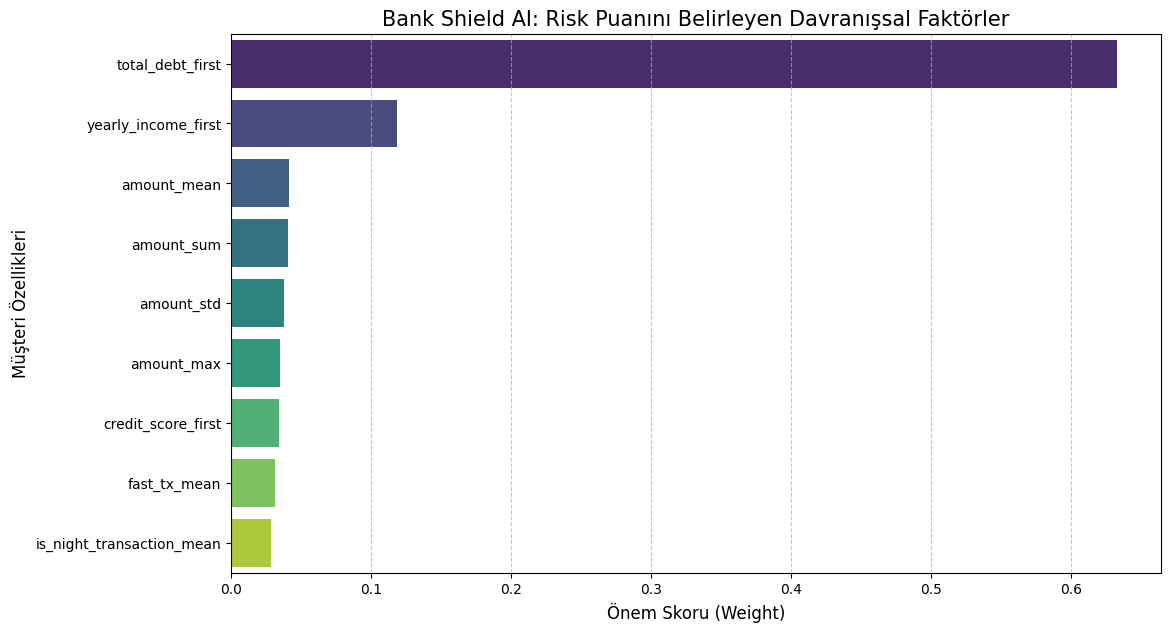

🔥 Riski Belirleyen İlk 3 Kritik Faktör:
1. total_debt_first: %63.28 etki
2. yearly_income_first: %11.84 etki
3. amount_mean: %4.10 etki


In [26]:
# Modelin en çok dikkat ettiği özellikleri çekelim
importances = pd.Series(rf_core.feature_importances_, index=X.columns).sort_values(ascending=False)

# Görselleştirme
plt.figure(figsize=(12, 7))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)

plt.title('Bank Shield AI: Risk Puanını Belirleyen Davranışsal Faktörler', fontsize=15)
plt.xlabel('Önem Skoru (Weight)', fontsize=12)
plt.ylabel('Müşteri Özellikleri', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("🔥 Riski Belirleyen İlk 3 Kritik Faktör:")
for i, (col, val) in enumerate(importances.head(3).items(), 1):
    print(f"{i}. {col}: %{val*100:.2f} etki")

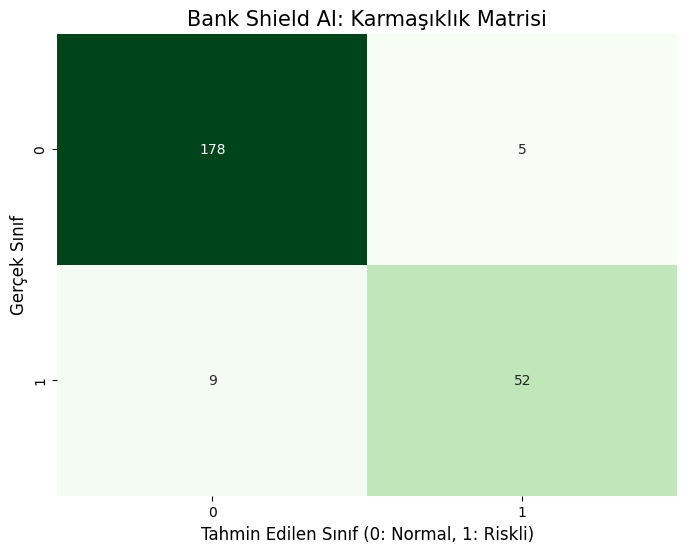


📊 DETAYLI MODEL PERFORMANS RAPORU
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       183
           1       0.91      0.85      0.88        61

    accuracy                           0.94       244
   macro avg       0.93      0.91      0.92       244
weighted avg       0.94      0.94      0.94       244

----------------------------------------
✅ Doğru Normal Tahmini (TN): 178
🚨 Yanlış Alarm (False Positive): 5
❌ Kaçırılan Riskli Müşteri (False Negative): 9
🔥 Yakalanan Yüksek Riskli (True Positive): 52
----------------------------------------


In [27]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tahminleri tekrar oluşturalım (Çünkü önceki hücrede sadece risk puanlarını hesaplamıştık)
y_pred = rf_core.predict(X_test)
y_proba = rf_core.predict_proba(X_test)[:, 1]

# 2. Karmaşıklık Matrisi Hesaplama
cm = confusion_matrix(y_test, y_pred)

# 3. Görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Bank Shield AI: Karmaşıklık Matrisi', fontsize=15)
plt.xlabel('Tahmin Edilen Sınıf (0: Normal, 1: Riskli)', fontsize=12)
plt.ylabel('Gerçek Sınıf', fontsize=12)
plt.show()

# 4. Detaylı Metrik Raporu
print("\n" + "="*40)
print("📊 DETAYLI MODEL PERFORMANS RAPORU")
print("="*40)
print(classification_report(y_test, y_pred))

# 5. Hata Türü Analizi
tn, fp, fn, tp = cm.ravel()
print("-" * 40)
print(f"✅ Doğru Normal Tahmini (TN): {tn}")
print(f"🚨 Yanlış Alarm (False Positive): {fp}")
print(f"❌ Kaçırılan Riskli Müşteri (False Negative): {fn}")
print(f"🔥 Yakalanan Yüksek Riskli (True Positive): {tp}")
print("-" * 40)

### ⚔️ Model Karşılaştırma: Random Forest vs. XGBoost

Ana modelimizin başarısını doğrulamak için modern veri biliminin en güçlü algoritmalarından biri olan **XGBoost** ile bir karşılaştırma (benchmarking) yapıyoruz. Amacımız, özellikle "Kaçırılan Riskli Müşteri" (False Negative) sayısını daha da aşağı çekip çekemeyeceğimizi görmek.

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. XGBoost Modelini Tanımlama
# scale_pos_weight: Dengesiz verilerde (914'e 305 gibi) azınlık sınıfı destekler
xgb_core = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=3, # 914/305 yaklaşık 3 katı olduğu için
    random_state=42,
    eval_metric='logloss'
)

# 2. Eğitim
print("🚀 XGBoost eğitiliyor...")
xgb_core.fit(X_train, y_train)

# 3. Tahmin ve Analiz
y_pred_xgb = xgb_core.predict(X_test)
y_proba_xgb = xgb_core.predict_proba(X_test)[:, 1]

# 4. Sonuçlar
print("\n" + "="*40)
print("⚔️ XGBoost PERFORMANS RAPORU")
print("="*40)
print(classification_report(y_test, y_pred_xgb))
print(f"📈 XGBoost ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Karmaşıklık Matrisi (Karşılaştırma için)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\n--- Hata Analizi (XGBoost) ---")
print(f"🚨 Yanlış Alarm (FP): {cm_xgb[0][1]}")
print(f"❌ Kaçırılan Risk (FN): {cm_xgb[1][0]}")

🚀 XGBoost eğitiliyor...

⚔️ XGBoost PERFORMANS RAPORU
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       183
           1       0.88      0.97      0.92        61

    accuracy                           0.96       244
   macro avg       0.93      0.96      0.95       244
weighted avg       0.96      0.96      0.96       244

📈 XGBoost ROC-AUC: 0.9970

--- Hata Analizi (XGBoost) ---
🚨 Yanlış Alarm (FP): 8
❌ Kaçırılan Risk (FN): 2


### ⚔️ Final Karşılaştırma: Random Forest vs. XGBoost

Bu bölümde, projenin iki güçlü adayı olan **Random Forest** ve **XGBoost** modellerini anahtar metrikler üzerinden kıyaslıyoruz. Bankacılık risk yönetiminde sadece doğruluk (accuracy) değil, özellikle **False Negative** (riskliyi kaçırma) oranının düşük olması hayati önem taşır.

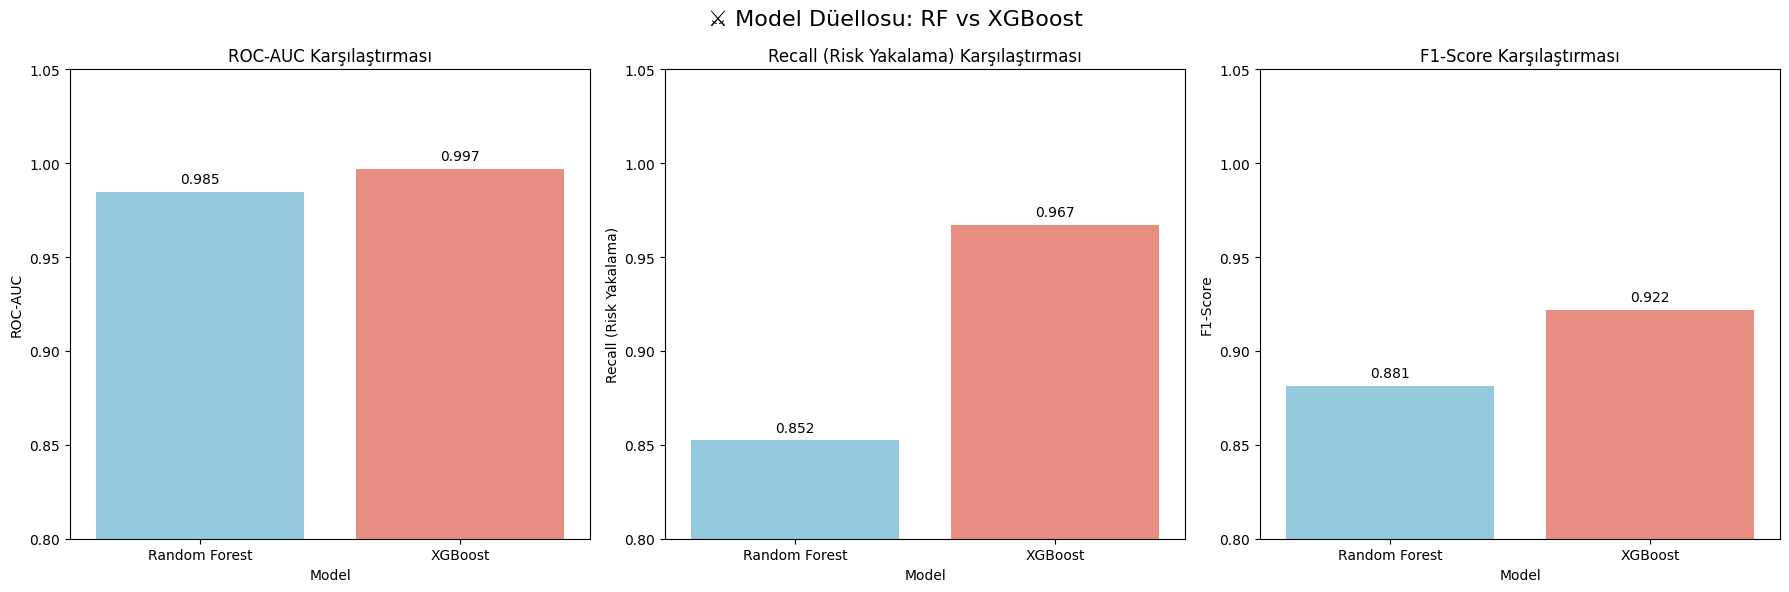

📝 HATA ANALİZİ TABLOSU
------------------------------
             Metrik  Random Forest  XGBoost
  Yanlış Alarm (FP)              5        8
Kaçırılan Risk (FN)              9        2


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

# 1. Metrikleri Hazırlayalım
models = ['Random Forest', 'XGBoost']
auc_scores = [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_xgb)]
recall_scores = [recall_score(y_test, y_pred), recall_score(y_test, y_pred_xgb)]
f1_scores = [f1_score(y_test, y_pred), f1_score(y_test, y_pred_xgb)]

# 2. Karşılaştırma DataFrame'i
comparison_df = pd.DataFrame({
    'Model': models,
    'ROC-AUC': auc_scores,
    'Recall (Risk Yakalama)': recall_scores,
    'F1-Score': f1_scores
})

# 3. Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('⚔️ Model Düellosu: RF vs XGBoost', fontsize=16)

metrics = ['ROC-AUC', 'Recall (Risk Yakalama)', 'F1-Score']
colors = ['skyblue', 'salmon']

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=comparison_df, ax=axes[i], palette=colors, hue='Model', legend=False)
    axes[i].set_title(f'{metric} Karşılaştırması')
    axes[i].set_ylim(0.8, 1.05) # Farkları net görmek için limit koyduk
    
    # Çubukların üzerine değerleri yazdıralım
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 4. Hata Özeti Tablosu
print("📝 HATA ANALİZİ TABLOSU")
print("-" * 30)
comparison_summary = pd.DataFrame({
    'Metrik': ['Yanlış Alarm (FP)', 'Kaçırılan Risk (FN)'],
    'Random Forest': [cm[0][1], cm[1][0]],
    'XGBoost': [cm_xgb[0][1], cm_xgb[1][0]]
})
print(comparison_summary.to_string(index=False))

In [30]:
# Hatalı tahminleri filtreleyelim
errors = X_test.copy()
errors['Gerçek'] = y_test
errors['Tahmin'] = y_pred_xgb

# Yanlış alarmlar (False Positives)
false_alarms = errors[(errors['Gerçek'] == 0) & (errors['Tahmin'] == 1)]
print(f"🚨 Yanlış Alarmların Ortalama Borç Oranı: {false_alarms['total_debt_first'].mean():.2f}")

🚨 Yanlış Alarmların Ortalama Borç Oranı: 96449.38


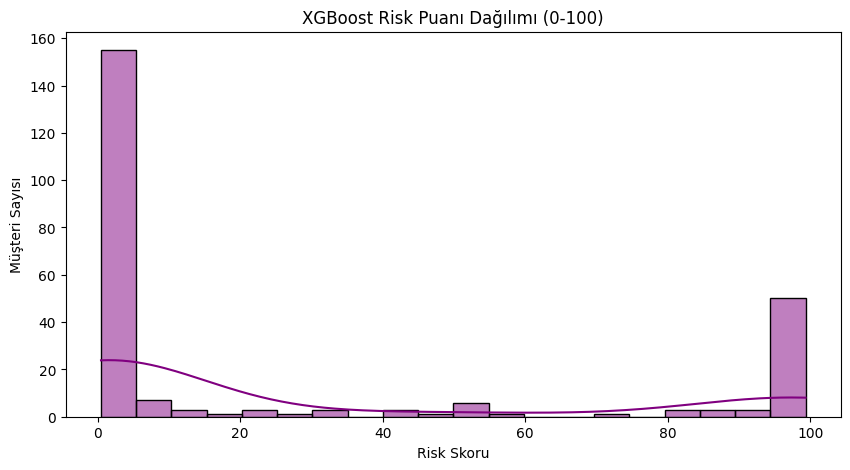

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(y_proba_xgb * 100, bins=20, kde=True, color='purple')
plt.title('XGBoost Risk Puanı Dağılımı (0-100)')
plt.xlabel('Risk Skoru')
plt.ylabel('Müşteri Sayısı')
plt.show()

### 📋 Model Girdi Protokolü

XGBoost modelimiz, tahmin üretmek için aşağıdaki 9 özelliğin tam listesine ve bu spesifik sıralamaya ihtiyaç duyar. Bu protokol, Streamlit arayüzünde kullanıcıdan veri alınırken veya veri setinden otomatik çekim yapılırken hata payını sıfıra indirmek için kullanılacaktır.

**Kritik Özellikler:**
1. **Borç/Gelir Faktörü:** En yüksek ağırlığa sahip belirleyiciler.
2. **Davranışsal Sinyaller:** Gece ve Hızlı işlem frekansları.
3. **İstatistiksel Sapmalar:** Harcama değişkenliği (`std`).

In [32]:
# Modelin beklediği kolonların tam listesi ve sırası
print("📝 Modelin Beklediği Girdiler:")
for i, feat in enumerate(X.columns, 1):
    print(f"{i}. {feat}")

📝 Modelin Beklediği Girdiler:
1. amount_mean
2. amount_std
3. amount_max
4. amount_sum
5. is_night_transaction_mean
6. fast_tx_mean
7. yearly_income_first
8. total_debt_first
9. credit_score_first


In [33]:
import joblib
import os

model_path = '../models'
if not os.path.exists(model_path):
    os.makedirs(model_path)

# Sadece modeli değil, eğitirken kullandığımız X kolonlarını da içine koyuyoruz
model_payload = {
    'model': xgb_core, # Şampiyon modelimiz
    'features': X.columns.tolist(), # Beklenen 9 girdinin tam listesi
    'threshold': threshold_value 
}

save_file = os.path.join(model_path, 'behavioral_risk_model.joblib')
joblib.dump(model_payload, save_file)

print(f"✅ İşlem Başarılı!")
print(f"📦 Model ve özellik listesi '{save_file}' konumuna kaydedildi.")

✅ İşlem Başarılı!
📦 Model ve özellik listesi '../models/behavioral_risk_model.joblib' konumuna kaydedildi.
